In [42]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

import aymansigmri as asm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Goal: Test SVD Function and determine scaling issue

In [43]:
## Load ZTE style data and transform to hankel matrix

zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.nufft_gridding(kspace=zte_radial_kspace, coords=zte_radial_coords)

data, n_coils, N_x, N_y = asm.hankel(kspace_cart_coils, w=5)
data_posthankel = asm.hankel_H_averaged(data_matrix = data, n_coils = kspace_cart_coils.shape[0], Nx = kspace_cart_coils.shape[1], Ny = kspace_cart_coils.shape[2], w=5)
#data_posthankel = asm.hankel_H(data_matrix = data, n_coils = kspace_cart_coils.shape[0], Nx = kspace_cart_coils.shape[1], Ny = kspace_cart_coils.shape[2], w=5)

### Check relative errors, specifically to determine tolerance for `np.allclose`

In [44]:
mag = np.abs(kspace_cart_coils)

print("Max kspace:", mag.max())
print("Mean kspace:", mag.mean())
print("Min nonzero kspace:", mag[mag > 0].min())

Max kspace: 0.256252560307442
Mean kspace: 0.00025187722717922434
Min nonzero kspace: 7.567337292154938e-08


### Test for inconsistencies between pre and post hankel data matrix

In [45]:
data_posthankel = asm.hankel_H(data_matrix = data, n_coils = kspace_cart_coils.shape[0], Nx = kspace_cart_coils.shape[1], Ny = kspace_cart_coils.shape[2], w=5)

## Testing on the hankel operators
np.allclose(kspace_cart_coils, data_posthankel, rtol=1e-5,atol=1e-7)

True

In [46]:
print(f"kspace_cart_coils shape: {kspace_cart_coils.shape}")
data, N_c, N_x, N_y = asm.hankel(kspace_cart_coils, w=5)


data_recon = asm.hankel_H(data, N_c, Nx=256, Ny=256, w=5)
print(f"Reconstructed shape: {data_recon.shape}")
print(f"Match: {np.allclose(kspace_cart_coils, data_recon)}")

kspace_cart_coils shape: (12, 256, 256)
Reconstructed shape: (12, 256, 256)
Match: True


In [47]:
error = np.abs(kspace_cart_coils - data_posthankel)
print(f"Max error: {error.max()}")
print(f"Mean error: {error.mean()}")
print(f"Relative error: {error.max() / np.abs(kspace_cart_coils).max()}")

Max error: 7.532749635690248e-09
Mean error: 5.6742456114185044e-12
Relative error: 2.9395802432774696e-08


In [48]:
### SVD Functions for building U, Sigma and Vh

def sig_val_thresholding(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=False)
    max_val = np.max(Sigma)
    thresh = max_val*zero_thresh
    arr = []
    for i in range(len(Sigma)):
        if Sigma[i] > thresh:
            arr.append(Sigma[i])
        else: arr.append(0)
    S_reduced = np.array(arr)
    return(U, S_reduced, Vh)

def svd_recon(u, s_reduced, vh):
    return u @ np.diag(s_reduced) @ vh

### Test Consistency
1. `np.allclose`
2. Divide to find average errors

In [49]:
arr1 = np.arange(1, 109).reshape(3, 6, 6)

dataarray, N_c, N_x, N_y = asm.hankel(arr1, 5)

arr2 = asm.hankel_H_averaged(dataarray, N_c, Nx=6, Ny=6, w=5)
np.allclose(arr1, arr2)

U, S_reduced, Vh = sig_val_thresholding(data=dataarray, zero_thresh=0.0)
data_recon = svd_recon(u=U, s_reduced=S_reduced, vh=Vh)

In [50]:
np.allclose(dataarray, data_recon)

True

In [51]:
## Load ZTE style data and transform to hankel matrix

data, n_coils, N_x, N_y = asm.hankel(kspace_cart_coils, w=5)

In [52]:
U, S_reduced, Vh = sig_val_thresholding(data=data, zero_thresh=0.0)
data_recon = svd_recon(u=U, s_reduced=S_reduced, vh=Vh)
kspace_recon = asm.hankel_H_averaged(data_matrix=data_recon, n_coils=12, Nx=256, Ny=256, w=5)
zte_recon = asm.nufft_degridding(cartesian_kspace=kspace_recon, coords=zte_radial_coords)

In [53]:
def nufft_gridding(kspace, coords):
    n_coils = kspace.shape[0]
    n_samples = kspace.shape[-1]
    dcf = np.sqrt(coords[..., 0]**2 + coords[..., 1]**2)
    imagegrid = sp.nufft_adjoint(kspace * dcf, coords, oshape=(n_coils, n_samples, n_samples))
    gridded_data = sp.fft(imagegrid, axes=(-2, -1))
    return gridded_data


def nufft_degridding(cartesian_kspace, coords):
    n_coils = cartesian_kspace.shape[0]
    image = sp.ifft(cartesian_kspace, axes=(-2, -1))
    radial_kspace = sp.nufft(image, coord=coords)
    dcf = np.sqrt(coords[..., 0]**2 + coords[..., 1]**2)
    return radial_kspace


In [59]:
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[...,1])
zte_radial_kspace_dcf = zte_recon / dcf

/var/folders/lp/mmccs9596xb7321q5q75xnj00000gn/T/ipykernel_35481/4007639537.py:1: RuntimeWarning: invalid value encountered in sqrt
  dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[...,1])
/var/folders/lp/mmccs9596xb7321q5q75xnj00000gn/T/ipykernel_35481/4007639537.py:2: RuntimeWarning: invalid value encountered in divide
  zte_radial_kspace_dcf = zte_recon / dcf


In [61]:
print(f"Numpy all close: {np.allclose(zte_radial_kspace_dcf, zte_recon)}")

error = np.abs(zte_radial_kspace_dcf - zte_recon)
print(f"Max error div dcf before vs after: {error.max()}")
print(f"Mean error div dcf before vs after: {error.mean()}")

Numpy all close: False
Max error div dcf before vs after: nan
Mean error div dcf before vs after: nan


In [54]:
print(f"Numpy all close: {np.allclose(data, data_recon)}")

error = np.abs(data - data_recon)
print(f"Max error hankel before vs after: {error.max()}")
print(f"Mean error hankel before vs after: {error.mean()}")
print(f"Relative error hankel before vs after: {error.max() / np.abs(kspace_cart_coils).max()}")

Numpy all close: False
Max error hankel before vs after: 2.266005481033062e-07
Mean error hankel before vs after: 1.0049386323096599e-10
Relative error hankel before vs after: 8.842859865729325e-07


In [55]:
print(f"Numpy all close: {np.allclose(kspace_cart_coils, kspace_recon)}")

error = np.abs(kspace_cart_coils - kspace_recon)
print(f"Max error hankel before vs after: {error.max()}")
print(f"Mean error hankel before vs after: {error.mean()}")
print(f"Relative error hankel before vs after: {error.max() / np.abs(kspace_cart_coils).max()}")

Numpy all close: True
Max error hankel before vs after: 4.395950982086263e-08
Mean error hankel before vs after: 3.3162481051438164e-11
Relative error hankel before vs after: 1.715475926098912e-07


In [56]:
print(f"Numpy all close: {np.allclose(zte_recon, zte_radial_kspace)}")

error = np.abs(zte_recon - zte_radial_kspace)
print(f"Max error zte before vs after: {error.max()}")
print(f"Mean error zte before vs after: {error.mean()}")
print(f"Relative error zte before vs after: {error.max() / np.abs(kspace_cart_coils).max()}")

Numpy all close: False
Max error zte before vs after: 0.27692326328101735
Mean error zte before vs after: 0.0015669103121890527
Relative error zte before vs after: 1.080665351982339


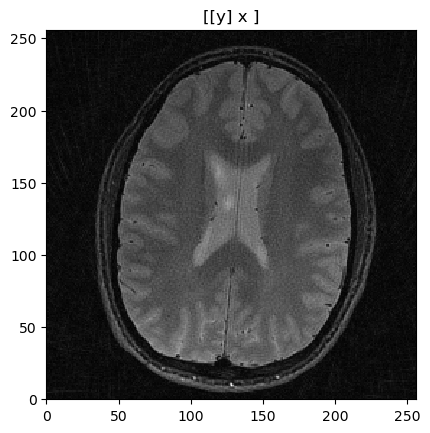

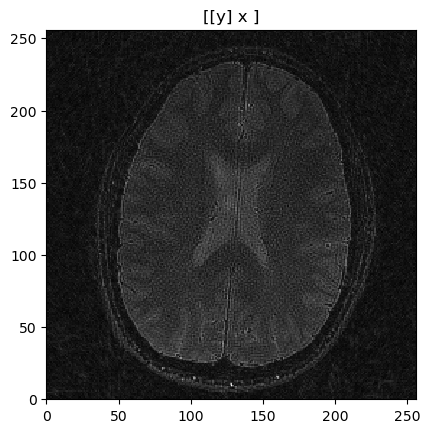

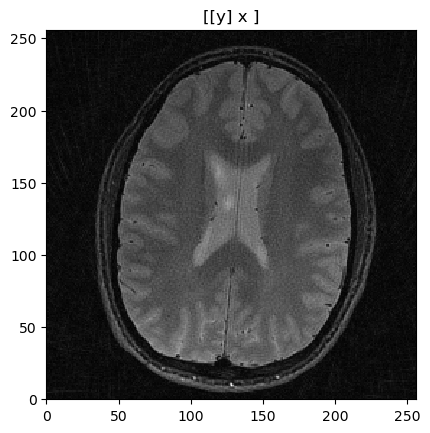

In [57]:
cart_recon_img_grid = sp.ifft(kspace_recon)
cart_recon_img_rss = np.sum(np.abs(cart_recon_img_grid)**2, axis=0)**0.5
pl.ImagePlot(cart_recon_img_rss)

asm.im_recon_zte(zte_recon, zte_radial_coords)
asm.im_recon_zte(zte_radial_kspace, zte_radial_coords)